In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping

Deep Neural Network with RMSProp Optimization

Import dataset

In [ ]:
df1 = pd.read_excel('data penjualan tembakau.xlsx')
df1.head()

,Tanggal,Harga (kg)
0,2023-01-01,51000
1,2023-01-02,51000
2,2023-01-03,51000
3,2023-01-04,51000
4,2023-01-05,51000


In [ ]:
len(df1)

365

In [ ]:
def convert2matrix(data_arr, look_back):
  X, Y = [], []
  for i in range(len(data_arr)-look_back):
    d=i+look_back
    X.append(data_arr[i:d])
    Y.append(data_arr[d])
  return np.array(X), np.array(Y)

Splitting data

In [ ]:
#Split data set into testing dataset and train dataset
train_size = 292
train, test =df1.values[0:train_size,1],df1.values[train_size:len(df1.values),1]
# setup look_back window
look_back = 30

In [ ]:
#convert dataset into right shape in order to input into the DNN
trainX, trainY = convert2matrix(train, look_back)
testX, testY = convert2matrix(test, look_back)

In [ ]:
trainX = trainX.astype('float32')
trainY = trainY.astype('float32')
testX = testX.astype('float32')
testY = testY.astype('float32')

Define neural network shape and compile model

In [ ]:
from keras.models import Sequential
from keras.layers import Dense
def model_dnn(look_back):
    model=Sequential()
    model.add(Dense(units=32, input_dim=look_back, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error',  optimizer=RMSprop(),metrics = ['mse', 'mae'])
    return model

Fit Model

In [ ]:
model=model_dnn(look_back)
history=model.fit(trainX,trainY, epochs=100, batch_size=30, verbose=1, validation_data=(testX,testY),callbacks=[EarlyStopping(monitor='val_loss', patience=10)],shuffle=False)

Epoch 1/100
9/9 [==============================] - 1s 31ms/step - loss: 2103834624.0000 - mse: 2103834368.0000 - mae: 38280.1562 - val_loss: 95946296.0000 - val_mse: 95946296.0000 - val_mae: 9699.1143
Epoch 2/100
9/9 [==============================] - 0s 5ms/step - loss: 45621780.0000 - mse: 45621780.0000 - mae: 5850.4824 - val_loss: 1798669.3750 - val_mse: 1798669.3750 - val_mae: 1072.5168
Epoch 3/100
9/9 [==============================] - 0s 5ms/step - loss: 8986251.0000 - mse: 8986251.0000 - mae: 1951.7795 - val_loss: 2817559.0000 - val_mse: 2817559.0000 - val_mae: 1353.6582
Epoch 4/100
9/9 [==============================] - 0s 5ms/step - loss: 9067479.0000 - mse: 9067479.0000 - mae: 1954.9711 - val_loss: 2374375.7500 - val_mse: 2374375.7500 - val_mae: 1242.6497
Epoch 5/100
9/9 [==============================] - 0s 7ms/step - loss: 9146419.0000 - mse: 9146419.0000 - mae: 1945.5657 - val_loss: 2122990.5000 - val_mse: 2122990.5000 - val_mae: 1172.3754
Epoch 6/100
9/9 [================

Model evaluation

In [ ]:
def model_loss(history):
    plt.figure(figsize=(8,4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Test Loss')
    plt.title('model loss')
    plt.ylabel('loss')
    plt.xlabel('epochs')
    plt.legend(loc='upper right')
    plt.show();

Train Root Mean Squared Error(RMSE): 2767.78; Train Mean Absolute Error(MAE) : 2030.05 
Test Root Mean Squared Error(RMSE): 2283.21; Test Mean Absolute Error(MAE) : 2009.46 


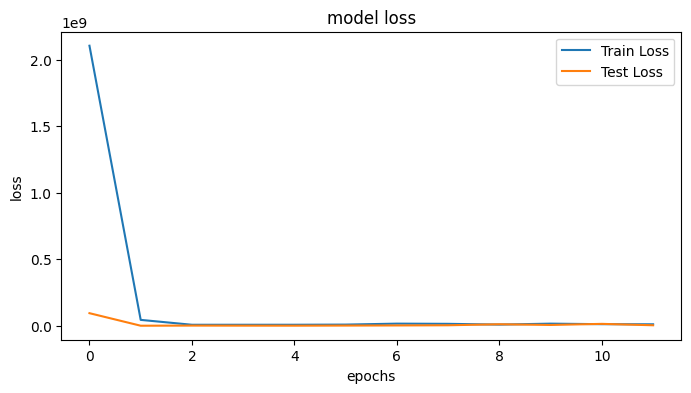

In [ ]:
train_score = model.evaluate(trainX, trainY, verbose=0)
print('Train Root Mean Squared Error(RMSE): %.2f; Train Mean Absolute Error(MAE) : %.2f '
% (np.sqrt(train_score[1]), train_score[2]))
test_score = model.evaluate(testX, testY, verbose=0)
print('Test Root Mean Squared Error(RMSE): %.2f; Test Mean Absolute Error(MAE) : %.2f '
% (np.sqrt(test_score[1]), test_score[2]))
model_loss(history)

Visualizing Prediction

In [ ]:
def prediction_plot(testY, test_predict):
      len_prediction=[x for x in range(len(testY))]
      plt.figure(figsize=(8,4))
      plt.plot(len_prediction, testY, marker='.', label="actual")
      plt.plot(len_prediction, test_predict, 'r', label="prediction")
      plt.tight_layout()
      sns.despine(top=True)
      plt.subplots_adjust(left=0.07)
      plt.ylabel('Harga Tembakau', size=15)
      plt.xlabel('Hari Ke-', size=15)
      plt.legend(fontsize=15)
      plt.show();

Train Data Fitted Plot

9/9 [==============================] - 0s 2ms/step


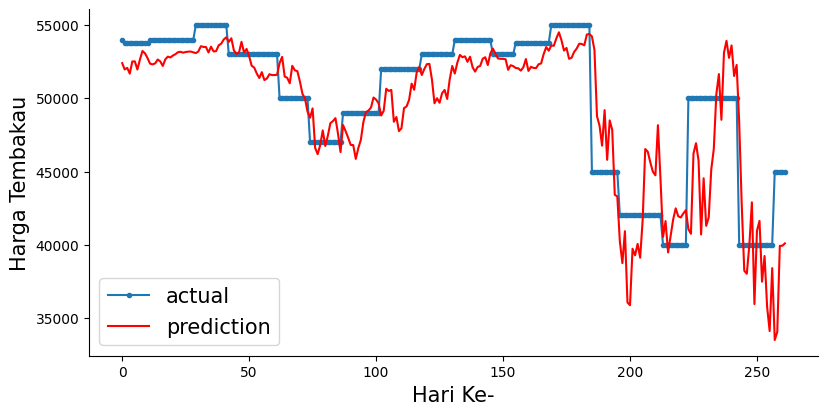

In [ ]:
prediction_plot(trainY, model.predict(trainX))

Test Data Fitted Plot

2/2 [==============================] - 0s 5ms/step


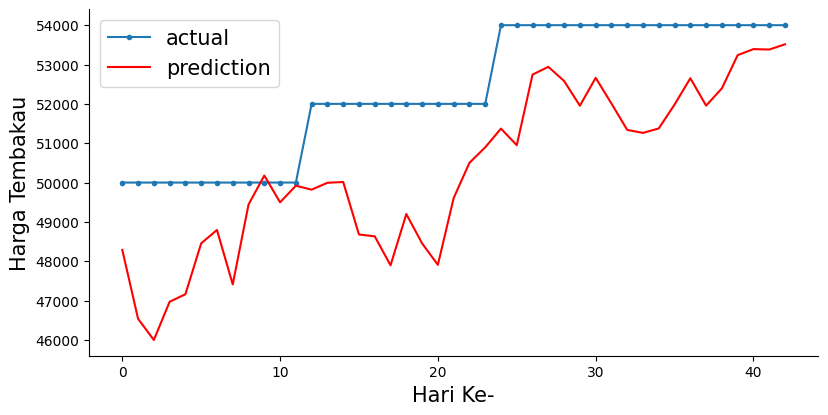

In [ ]:
prediction_plot(testY, model.predict(testX))

Forecasting

In [ ]:
# Lakukan peramalan untuk 10 hari ke depan
last_data = testX[-1]  # Data terakhir dari data asli
forecast = []

for _ in range(10): # Jika ingin melakukan peramalan untuk lebih dari 10 hari ke depan, silahkan ubah angka 10 yang ada di range()
    prediction = model.predict(np.array([last_data]))  # Lakukan peramalan untuk data terakhir
    forecast.append(prediction.flatten()[0])  # Tambahkan hasil peramalan ke dalam forecast
    last_data = np.append(last_data[1:], prediction)  # Update data terakhir dengan hasil peramalan

print(forecast)

1/1 [==============================] - 0s 19ms/step
[53513.637, 53448.406, 52423.504, 51549.34, 50989.69, 50700.57, 50646.29, 50941.355, 50443.066, 51281.785]


In [ ]:
forecast_mat = np.array(forecast)
print(forecast_mat)

[53513.637 53448.406 52423.504 51549.34  50989.69  50700.57  50646.29
 50941.355 50443.066 51281.785]


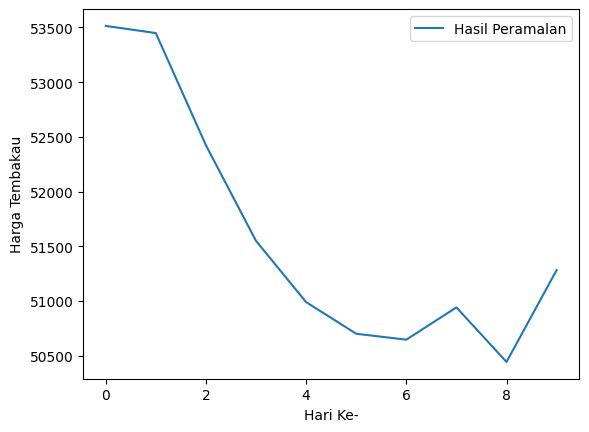

In [ ]:
# Plot hasil forecast
plt.plot(range(0, len(forecast_mat)), forecast_mat.flatten(), label='Hasil Peramalan')
plt.xlabel('Hari Ke-')
plt.ylabel('Harga Tembakau')
plt.legend()
plt.show()